In [1]:
from regression_diagnostics import run_full_regression_diagnostics, format_regression_outputs

from SymbolicDSGE import ModelParser, DSGESolver, Shock
from SymbolicDSGE.utils import DenHaanMarcet
from SymbolicDSGE.bayesian import make_prior

from numpy import log
import numpy as np

from scipy.linalg import cholesky, solve_triangular
from scipy.stats import gaussian_kde, norm

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import cProfile

_MEAS_ERR_SCALE = 0.05
_FIGSIZE_1D = (10, 6)
_FIGSIZE_2D = (12, 6)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
# Load reference model
parser = ModelParser("../../MODELS/misspec_test/reference.yaml")
config, kalman = parser.get_all()
solver = DSGESolver(config, kalman)

comp = solver.compile(
    n_state=3,
    n_exog=3,
)
sol = solver.solve(
    comp,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
)



In [3]:
# Load Misspecified DGP
parser_dgp = ModelParser("../../MODELS/misspec_test/misspec.yaml")
config_dgp, kalman_dgp = parser_dgp.get_all()
solver_dgp = DSGESolver(config_dgp, kalman_dgp)
comp_dgp = solver_dgp.compile(
    n_state=3,
    n_exog=3,
)
sol_dgp = solver_dgp.solve(
    comp_dgp,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
)

In [4]:
# Large Sample Simulations
gz_large = lambda seed: Shock(10_000, "norm", multivar=True, seed=seed).shock_generator()
r_large = lambda seed: Shock(10_000, "norm", multivar=False, seed=seed).shock_generator()
shocks_large = {"g,z": gz_large(6), "r": r_large(7)}

sim1 = sol_dgp.sim(
    T=10_000,
    shocks=shocks_large,
    observables=True,
)

sim2 = sol.sim(
    T=10_000,
    shocks=shocks_large,
    observables=True,
)

In [5]:
T = 200
gz_gen = lambda seed: Shock(T, "norm", multivar=True, seed=seed).shock_generator()
r_gen = lambda seed: Shock(T, "norm", multivar=False, seed=seed).shock_generator()

sim_dgp = sol_dgp.sim(
    T=T,
    shocks={"g,z": gz_gen(0), "r": r_gen(1)},
    observables=True,
)

In [6]:
# Use DGP observables as kalman filter targets in reference model
obs = np.column_stack([sim_dgp["OutGap"], sim_dgp["Infl"], sim_dgp["Rate"]])[1:, :]
err_var = np.var(np.column_stack([sim1["OutGap"], sim1["Infl"], sim1["Rate"]]), axis=0)  # use large sample variance as error variance
err_scale = _MEAS_ERR_SCALE * err_var

rng = np.random.default_rng(0)
get_err = lambda shape: rng.normal(scale=np.sqrt(err_scale), size=shape)
obs += get_err(obs.shape)


kf = sol.kalman(
    y=obs,
    filter_mode="linear",
    estimate_R_diag=False,
    R=np.diag(err_scale),
)

N, n_obs = kf.innov.shape
std_innov = np.empty_like(kf.innov)

for t in range(N):
    S_t = 0.5 * (kf.S[t] + kf.S[t].T)  # optional symmetry cleanup
    L_t = cholesky(S_t, lower=True)
    std_innov[t] = solve_triangular(L_t, kf.innov[t], lower=True)

print("Noise Covariance:\n", np.diag(err_scale).round(3))

Noise Covariance:
 [[0.592 0.    0.   ]
 [0.    0.82  0.   ]
 [0.    0.    0.039]]


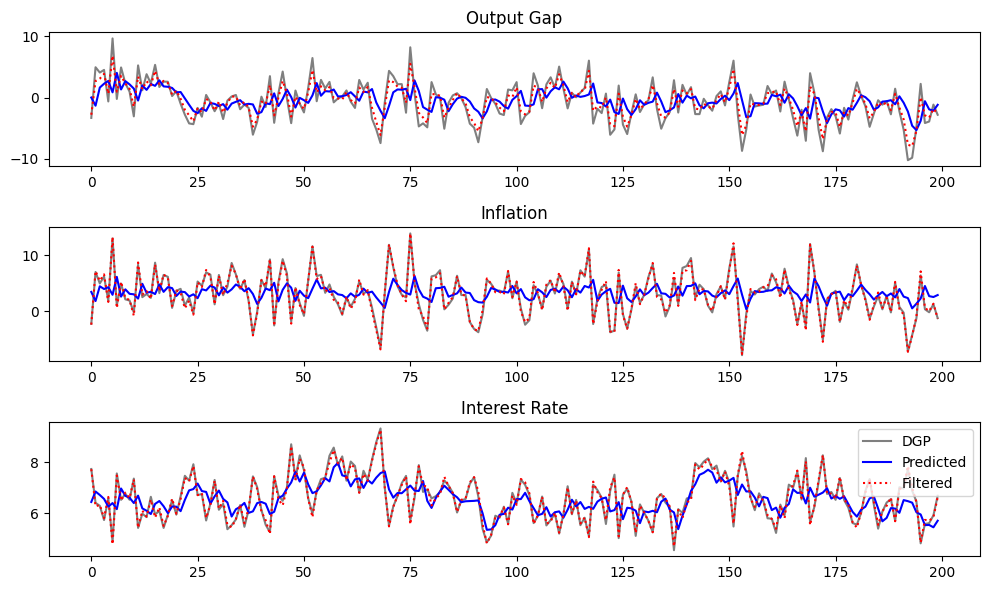

In [7]:
# Plot Filter Outputs
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.5)
ax[0].plot(range(T), kf.y_pred[:, 0], label="Predicted", color="blue")
ax[0].plot(range(T), kf.y_filt[:, 0], label="Filtered", color="red", linestyle=":")
ax[0].set_title("Output Gap")

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.5)
ax[1].plot(range(T), kf.y_pred[:, 1], label="Predicted", color="blue")
ax[1].plot(range(T), kf.y_filt[:, 1], label="Filtered", color="red", linestyle=":")
ax[1].set_title("Inflation")

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.5)
ax[2].plot(range(T), kf.y_pred[:, 2], label="Predicted", color="blue")
ax[2].plot(range(T), kf.y_filt[:, 2], label="Filtered", color="red", linestyle=":")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

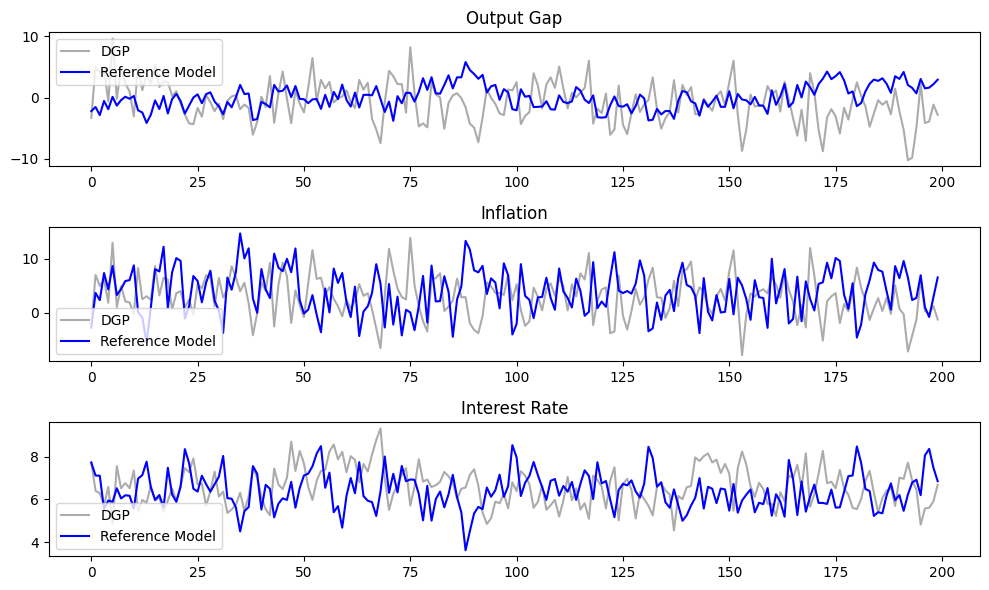

In [8]:
# Simulation against DGP
sim_ref = sol.sim(
    T=T,
    shocks={"g,z": gz_gen(2), "r": r_gen(3)},
    observables=True,
)

ref = np.column_stack([sim_ref["OutGap"], sim_ref["Infl"], sim_ref["Rate"]])[1:, :]

fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.33)
ax[0].plot(range(T), ref[:, 0], label="Reference Model", color="blue")
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.33)
ax[1].plot(range(T), ref[:, 1], label="Reference Model", color="blue")
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.33)
ax[2].plot(range(T), ref[:, 2], label="Reference Model", color="blue")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

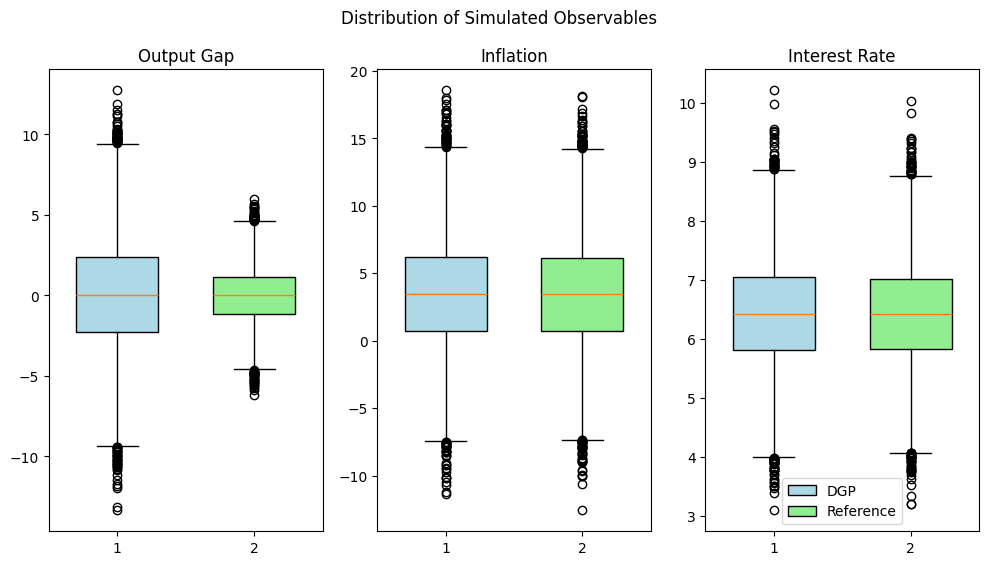

In [9]:
obs_dgp = np.column_stack([sim1["OutGap"], sim1["Infl"], sim1["Rate"]])[1:, :]
obs_dgp += get_err(obs_dgp.shape)

fig, ax = plt.subplots(1, 3, figsize=_FIGSIZE_2D)

plt.suptitle("Distribution of Simulated Observables")

ax[0].boxplot(obs_dgp[:, 0], positions=[1], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightblue"), label="DGP")
ax[0].boxplot(sim2["OutGap"], positions=[2], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightgreen"), label="Reference")
ax[0].set_title("Output Gap")

ax[1].boxplot(obs_dgp[:, 1], positions=[1], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightblue"), label="DGP")
ax[1].boxplot(sim2["Infl"], positions=[2], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightgreen"), label="Reference")
ax[1].set_title("Inflation")

ax[2].boxplot(obs_dgp[:, 2], positions=[1], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightblue"), label="DGP")
ax[2].boxplot(sim2["Rate"], positions=[2], widths=0.6, patch_artist=True, boxprops=dict(facecolor="lightgreen"), label="Reference")
ax[2].set_title("Interest Rate")
ax[2].legend()

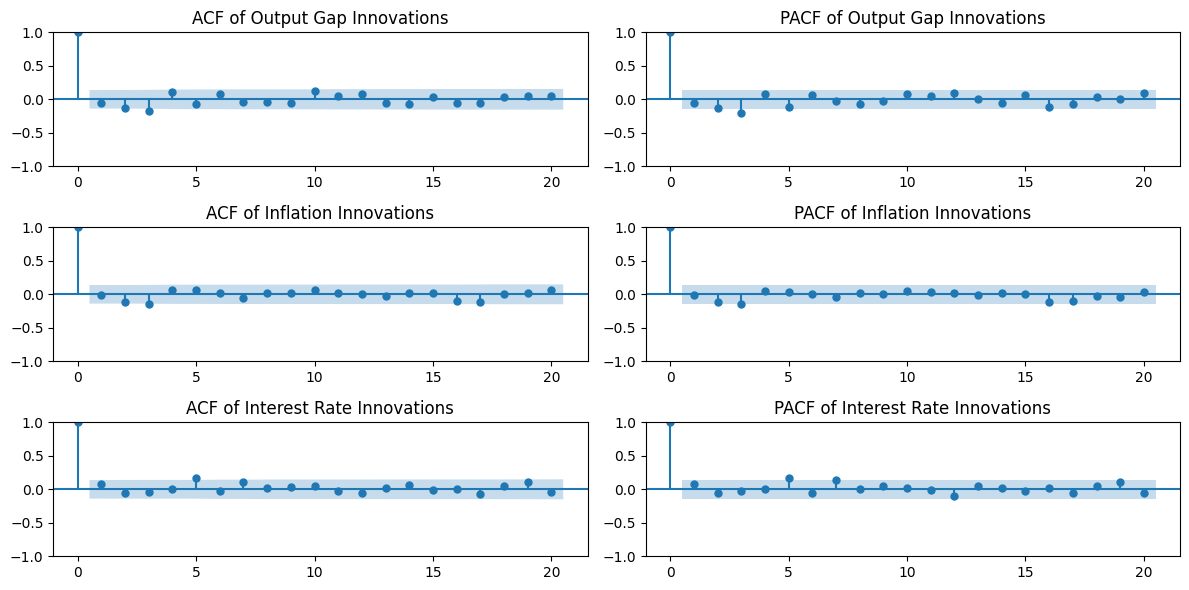

Ljung-Box test for Output Gap Innovations:
    LB Stat=0.54
    p-value=0.4614

Ljung-Box test for Inflation Innovations:
    LB Stat=0.00
    p-value=0.9580

Ljung-Box test for Interest Rate Innovations:
    LB Stat=1.37
    p-value=0.2425



In [10]:
# Plot AFC/PACF of kalman innovations to see if the misspecification appears in the form of serial correlation

fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plot_acf(std_innov[:, 0], ax=ax[0, 0], lags=20)
plot_pacf(std_innov[:, 0], ax=ax[0, 1], lags=20)
ax[0, 0].set_title("ACF of Output Gap Innovations")
ax[0, 1].set_title("PACF of Output Gap Innovations")

plot_acf(std_innov[:, 1], ax=ax[1, 0], lags=20)
plot_pacf(std_innov[:, 1], ax=ax[1, 1], lags=20)
ax[1, 0].set_title("ACF of Inflation Innovations")
ax[1, 1].set_title("PACF of Inflation Innovations")

plot_acf(std_innov[:, 2], ax=ax[2, 0], lags=20)
plot_pacf(std_innov[:, 2], ax=ax[2, 1], lags=20)
ax[2, 0].set_title("ACF of Interest Rate Innovations")
ax[2, 1].set_title("PACF of Interest Rate Innovations")

plt.tight_layout()
plt.show()
# Apply Ljung-Box test to check for serial correlation in innovations
for i, var in enumerate(["Output Gap", "Inflation", "Interest Rate"]):
    test = acorr_ljungbox(std_innov[:, i], lags=20)
    print(
        f"Ljung-Box test for {var} Innovations:\n    LB Stat={test['lb_stat'].iloc[0]:.2f}\n    p-value={test['lb_pvalue'].iloc[0]:.4f}\n"
    )

In [76]:
mu = std_innov.mean(axis=0)
Sigma = np.cov(std_innov, rowvar=False)

print("Mean:", mu.round(3))
print("Covariance:\n", Sigma.round(3))
print("Cov elementwise distance from identity:\n", np.abs(np.cov(std_innov, rowvar=False) - np.eye(n_obs)).round(3))

Mean: [-0.16   0.062  0.034]
Covariance:
 [[ 3.733 -1.495  0.572]
 [-1.495  0.957 -0.106]
 [ 0.572 -0.106  1.048]]
Cov elementwise distance from identity:
 [[2.733 1.495 0.572]
 [1.495 0.043 0.106]
 [0.572 0.106 0.048]]


In [13]:
diag = run_full_regression_diagnostics(kf)
fmt_out = format_regression_outputs(diag, round_to=3)

fmt_out["orthogonalization_summary"]

,target,model,regressor,coef,std_error,t_stat,p_value,r2
0,Pi,Pi ~ r + x,r,-0.270,0.099,-2.726,0.007,0.517
1,Pi,Pi ~ r + x,x,0.119,0.008,14.226,0.000,0.517
2,x,x ~ r + Pi,r,1.081,0.597,1.811,0.072,0.507
3,x,x ~ r + Pi,Pi,4.247,0.299,14.226,0.000,0.507
4,r,r ~ x + Pi,x,0.015,0.008,1.811,0.072,0.036
5,r,r ~ x + Pi,Pi,-0.135,0.049,-2.726,0.007,0.036


In [20]:
order = {"Pi": 0, "x": 1, "r": 2}
print("Innovations on orthogonalized predicted states:\n")
df_orth = fmt_out["measurement_regressions_orthogonalized_long"]

df_orth.loc[df_orth["measurement"] == "Rate"].sort_values(by="predictor", key= lambda s: s.map(order))

Innovations on orthogonalized predicted states:



,measurement,predictor,coef,standardized_coef,std_error,t_stat,p_value,r2
6,Rate,Pi,-0.091,-0.024,0.272,-0.336,0.737,0.001
7,Rate,x,0.057,0.089,0.045,1.255,0.211,0.008
8,Rate,r,0.115,0.021,0.385,0.299,0.765,0.000


In [21]:
print("Innovations on raw predicted states:\n")
df_raw = fmt_out["measurement_regressions_raw_long"]

df_raw.loc[df_raw["measurement"] == "Rate"].sort_values(by="predictor", key= lambda s: s.map(order))

Innovations on raw predicted states:



,measurement,predictor,coef,standardized_coef,std_error,t_stat,p_value,r2
8,Rate,Pi,0.138,0.052,0.189,0.730,0.466,0.003
7,Rate,x,0.046,0.102,0.032,1.442,0.151,0.010
6,Rate,r,0.134,0.025,0.377,0.354,0.723,0.001


Notice that output gap measurement regressions show Pi has retained a non-zero coefficient post-orthogonalization. This shows that the OLS based diagnostic identifies that Pi should exist in some capacity within the output gap measurement. Knowing that the planted misspecification was exactly `OutGap = OutGap + 2Pi(t)` the OLS finding is correctly identifying the equation/variable pair and localizing the misspecification correctly.

We know Pi(t) should be tested as a component of OutGap based on this result. However, the OLS coefficient is not solved under the complete RE system. Hence the coefficient itself is not reliable. Therefore, we will include Pi(t) in the measurement with a estimated coefficient, keeping all other parameters constant.

The model below defines a variable `Pi_coef = 0.0`. (We know the coefficient should be 2.0 but a real-life application should use a high-entropy prior assuming $H_0: \beta_{\Pi}=0$) We then estimate the coefficient and inspect the results.

In [77]:
parser_aug = ModelParser("../../MODELS/misspec_test/augmented_reference.yaml")
config_aug, kalman_aug = parser_aug.get_all()
solver_aug = DSGESolver(config_aug, kalman_aug)
comp_aug = solver_aug.compile(
    n_state=3,
    n_exog=3,
)
priors = {
    "Pi_coef": make_prior(
        'normal',
        parameters={"mean": 0.0, "std": 4.0, "random_state":0,},
        transform="identity",  # Keep the coefficient unconstrained
    ),
}

estim = lambda: solver_aug.estimate_and_solve(
    compiled=comp_aug,
    method="mcmc",
    n_draws=25_000,
    burn_in=10_000,
    thin=2,
    posterior_point="mean",
    proposal_scale=1.0,  # Default=0.1 - increased to allow for more exploration given the high-entropy prior
    y=obs,
    priors=priors,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
    random_state=0,
)
res_aug, sol_aug = estim()

MCMC sampling concluded in 92.90 seconds with 645.85 iterations per second.
[Estimator:mcmc] BK stability warnings encountered during search: 0


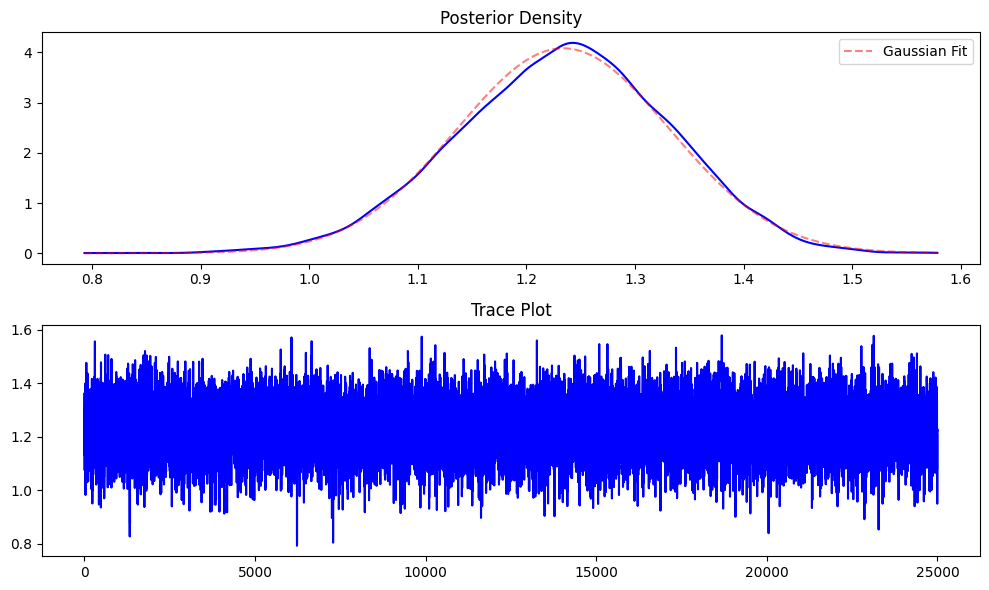

In [80]:
pi_coeff_trace = res_aug.samples[:, 0]

kde = gaussian_kde(pi_coeff_trace)
norm_fit = norm(loc=pi_coeff_trace.mean(), scale=pi_coeff_trace.std())
x_range = np.linspace(pi_coeff_trace.min(), pi_coeff_trace.max(), 1000)
fig, ax = plt.subplots(2, 1, figsize=_FIGSIZE_1D)

ax[0].plot(x_range, kde(x_range), color="blue")
ax[0].plot(x_range, norm_fit.pdf(x_range), linestyle="--", color="red", alpha=0.5, label="Gaussian Fit")
ax[0]
ax[0].set_title("Posterior Density")
ax[0].legend()

ax[1].plot(pi_coeff_trace, color="blue")
ax[1].set_title("Trace Plot")

plt.tight_layout()
plt.show()

In [78]:
sol_aug.config.calibration.parameters["Pi_coef"].round(3)

np.float64(1.234)

In [79]:
tuple(map(lambda x: float(x.round(3)), res_aug.hpd_intervals()["Pi_coef"]))

(1.045, 1.423)

In [81]:
res_aug.accept_rate

np.float64(0.4398166666666667)

The estimation results are quite successful even under the very loose prior. The coefficient of the misspecification term is almost exactly recovered by this methodology. In a real life scenario, however, we would not be aware of that at this point. Therefore we should confirm the validity of the recovered parameter. To do so, we run through the same OLS diagnostics and KF checks. But we can also estimate the measurement error as a shorthand, crude check. With this coefficient, the augmented model is almost 1-to-1 with the misspecified DGP, therefore an estimated $R$ matrix (measurement error covariance) should be very close to 0 in this case.

In [82]:
kf_aug = sol_aug.kalman(
    y=obs,
    filter_mode="linear",
    estimate_R_diag=False,
)
round(kf_aug.loglik, 2)

-1415.32

## Diagnostics of the Augmented Model

We will continue with the parameter-estimated augmentation and formalize the fact that the misspecification was correctly discovered within margins. To do so, we will run all of the tests that were ran for the initial misspecified model and conduct a comparison of outcomes.

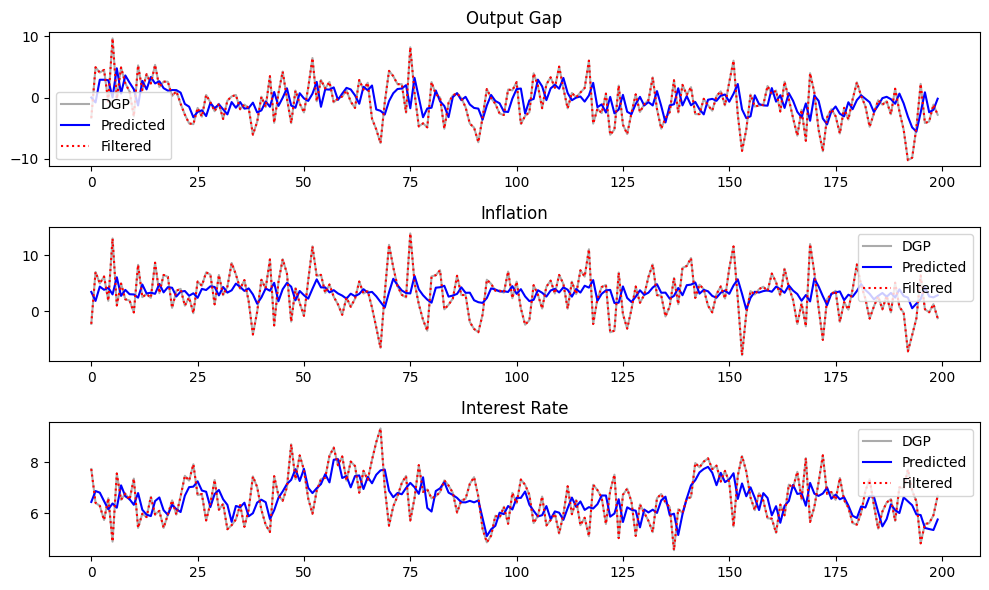

In [83]:
# Plot KF Outputs for Augmented Model
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)
ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.33)
ax[0].plot(range(T), kf_aug.y_pred[:, 0], label="Predicted", color="blue")
ax[0].plot(range(T), kf_aug.y_filt[:, 0], label="Filtered", color="red", linestyle=":")
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.33)
ax[1].plot(range(T), kf_aug.y_pred[:, 1], label="Predicted", color="blue")
ax[1].plot(range(T), kf_aug.y_filt[:, 1], label="Filtered", color="red", linestyle=":")
ax[1]. set_title("Inflation")
ax[1].legend()

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.33)
ax[2].plot(range(T), kf_aug.y_pred[:, 2], label="Predicted", color="blue")
ax[2].plot(range(T), kf_aug.y_filt[:, 2], label="Filtered", color="red", linestyle=":")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

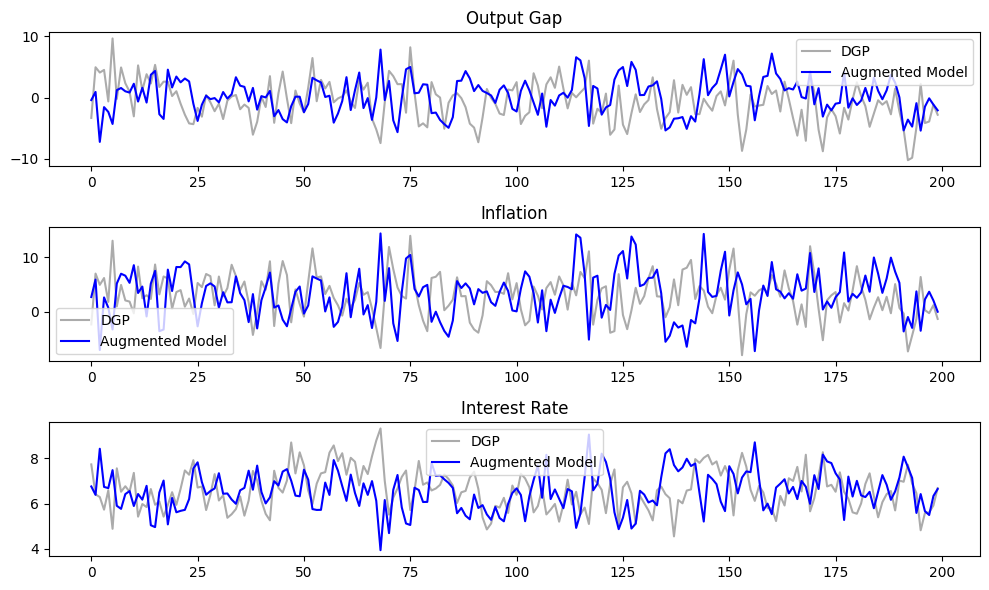

In [84]:
# Simulation against DGP for Augmented Model

sim_aug = sol_aug.sim(
    T=T,
    shocks={"g,z": gz_gen(4), "r": r_gen(5)},
    observables=True,
)
aug = np.column_stack([sim_aug["OutGap"], sim_aug["Infl"], sim_aug["Rate"]])[1:, :]
fig, ax = plt.subplots(3, 1, figsize=_FIGSIZE_1D)

ax[0].plot(range(T), obs[:, 0], label="DGP", color="black", alpha=0.33)
ax[0].plot(range(T), aug[:, 0], label="Augmented Model", color="blue")
ax[0].set_title("Output Gap")
ax[0].legend()

ax[1].plot(range(T), obs[:, 1], label="DGP", color="black", alpha=0.33)
ax[1].plot(range(T), aug[:, 1], label="Augmented Model", color="blue")
ax[1].set_title("Inflation")
ax[1].legend()

ax[2].plot(range(T), obs[:, 2], label="DGP", color="black", alpha=0.33)
ax[2].plot(range(T), aug[:, 2], label="Augmented Model", color="blue")
ax[2].set_title("Interest Rate")
ax[2].legend()

plt.tight_layout()
plt.show()

### Simulation Accuracy Test

We now have realized simulations representing the DGP and Augmentation. We can conduct a Den Haan - Marcet test to determine whether the DGP-simulated states are statistically distinguishable from the Augmented Model class. This test is a simulation test targetting the laws of motion, which we know are identical between the DGP and Augmented model. Therefore we expect a clean pass and a p-value of 1.0 here. This is applied as a consistency check before the measurement residuals are test.

In [85]:
dhm = DenHaanMarcet(sol_dgp)  # Initialize test space with DGP, this means the misspecification is embedded in the FOCs
res = dhm.from_state_path(
    states=sim_aug["_X"],
    equation_idx=[0, 1, 2],  # Test first-orders, not the AR(1) shock propagation equations
    instrument_idx=[0,1,2,3,4],  # All instruments
    use_conditional_expectation=True, # (t+1) variables computed as deterministic law of motion (shock=0) at time t.
)
res.p_value

1.0

### Marginal LR Test Conditional on $\theta_0$

We can conduct a LR test holding parameters of the $\theta_0$ constant among models and DGP to assess the marginal likelihood contribution of the added component.

In [88]:
from scipy.stats import chi2
res_mle, sol_mle = solver_aug.estimate_and_solve(
    compiled=comp_aug,
    method="mle",
    y=obs,
    estimated_params=["Pi_coef"],
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
    R=np.diag(err_scale),
)
mle_aug_kf = sol_mle.kalman(
    y=obs,
    filter_mode="linear",
    estimate_R_diag=False,
    R=np.diag(err_scale),
)

l_aug = mle_aug_kf.loglik
l_raw = kf.loglik

lr = 2 * (l_aug - l_raw)
print("Estimated Coefficient: ", sol_mle.config.calibration.parameters["Pi_coef"].round(3))
print(f"Log-Likelihood of Raw Reference Model: {l_raw:.2f}")
print(f"Log-Likelihood of Augmented Model: {l_aug:.2f}")
print(f"Likelihood Ratio Statistic: {lr:.2f}")
p_value_lr = 1 - chi2.cdf(lr, df=1)  # one additional parameter in augmented model
print(f"P-value of LR Test: {p_value_lr:.4f}")

[Estimator:mle] BK stability warnings encountered during search: 0
Estimated Coefficient:  1.926
Log-Likelihood of Raw Reference Model: -1265.13
Log-Likelihood of Augmented Model: -1003.80
Likelihood Ratio Statistic: 522.65
P-value of LR Test: 0.0000


In [87]:
innov_mle = mle_aug_kf.innov

std_innov_mle = np.empty_like(innov_mle)
for t in range(N):
    S_t = 0.5 * (mle_aug_kf.S[t] + mle_aug_kf.S[t].T)  # optional symmetry cleanup
    L_t = cholesky(S_t, lower=True)
    std_innov_mle[t] = solve_triangular(L_t, mle_aug_kf.innov[t], lower=True)

print("Mean:\n", std_innov_mle.mean(axis=0).round(3))
print("Covariance:\n", np.cov(std_innov_mle, rowvar=False).round(3))
print("Cov elementwise distance from identity:\n", np.abs(np.cov(std_innov_mle, rowvar=False) - np.eye(n_obs)).round(3))

Mean:
 [-0.107  0.07   0.042]
Covariance:
 [[ 0.865 -0.075  0.073]
 [-0.075  1.025 -0.039]
 [ 0.073 -0.039  0.982]]
Cov elementwise distance from identity:
 [[0.135 0.075 0.073]
 [0.075 0.025 0.039]
 [0.073 0.039 0.018]]


In [35]:
res_mle

OptimizationResult(kind='mle', x=array([1.56163196]), theta={'beta': np.float64(0.971), 'kappa': np.float64(0.58), 'tau_inv': np.float64(1.86), 'psi_pi': np.float64(2.19), 'psi_x': np.float64(0.3), 'rho_r': np.float64(0.84), 'rho_g': np.float64(0.83), 'rho_z': np.float64(0.85), 'pi_star': np.float64(3.43), 'r_star': np.float64(3.01), 'sig_r': np.float64(0.18), 'sig_g': np.float64(0.18), 'sig_z': np.float64(0.64), 'rho_gz': np.float64(0.36), 'meas_infl': np.float64(1e-06), 'meas_rate': np.float64(1e-06), 'meas_outgap': np.float64(1e-06), 'meas_rho_ir': np.float64(0.0), 'meas_rho_gi': np.float64(0.0), 'meas_rho_gr': np.float64(0.0), 'Pi_coef': np.float64(1.5616319551350426)}, success=True, message='CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', fun=np.float64(1005.8661112754986), loglik=np.float64(-1005.8661112754986), logprior=np.float64(0.0), logpost=np.float64(-1005.8661112754986), nfev=12, nit=4, raw=  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: T

## Serial Autocorrelation tests for the Augmented Model

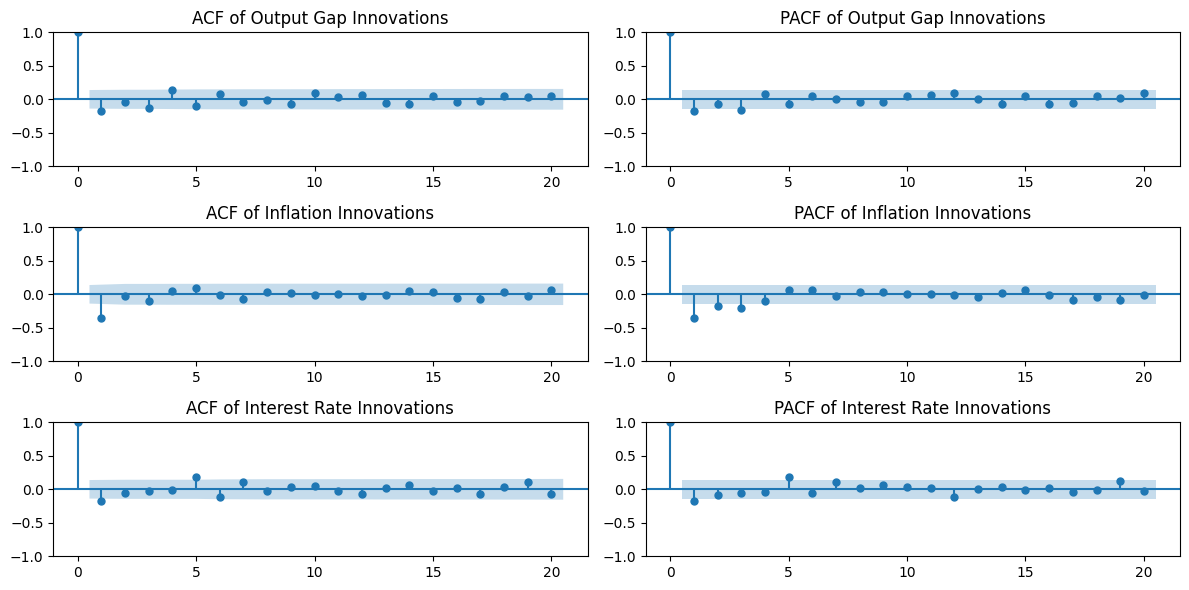

Ljung-Box test for Output Gap Innovations (Augmented Model):
    LB Stat=6.27
    p-value=0.0123

Ljung-Box test for Inflation Innovations (Augmented Model):
    LB Stat=25.75
    p-value=0.0000

Ljung-Box test for Interest Rate Innovations (Augmented Model):
    LB Stat=5.88
    p-value=0.0153



In [36]:
std_innov_aug = np.empty_like(kf_aug.innov)
for t in range(N):
    S_t = 0.5 * (kf_aug.S[t] + kf_aug.S[t].T)  # optional symmetry cleanup
    L_t = cholesky(S_t, lower=True)
    std_innov_aug[t] = solve_triangular(L_t, kf_aug.innov[t], lower=True)

fig, ax = plt.subplots(3, 2, figsize=_FIGSIZE_2D)

plot_acf(std_innov_aug[:, 0], ax=ax[0, 0], lags=20, title="ACF of Output Gap Innovations", label="Augmented Model")
plot_pacf(std_innov_aug[:, 0], ax=ax[0, 1], lags=20, title="PACF of Output Gap Innovations", label="Augmented Model")

plot_acf(std_innov_aug[:, 1], ax=ax[1, 0], lags=20, title="ACF of Inflation Innovations", label="Augmented Model")
plot_pacf(std_innov_aug[:, 1], ax=ax[1, 1], lags=20, title="PACF of Inflation Innovations", label="Augmented Model")

plot_acf(std_innov_aug[:, 2], ax=ax[2, 0], lags=20, title="ACF of Interest Rate Innovations", label="Augmented Model")
plot_pacf(std_innov_aug[:, 2], ax=ax[2, 1], lags=20, title="PACF of Interest Rate Innovations", label="Augmented Model")


plt.tight_layout()
plt.show()

# Ljung-Box test for Augmented Model Innovations
for i, var in enumerate(["Output Gap", "Inflation", "Interest Rate"]):
    test = acorr_ljungbox(std_innov_aug[:, i], lags=20)
    print(
        f"Ljung-Box test for {var} Innovations (Augmented Model):\n    LB Stat={test['lb_stat'].iloc[0]:.2f}\n    p-value={test['lb_pvalue'].iloc[0]:.4f}\n"
    )

In [37]:
mu_aug = std_innov_aug.mean(axis=0)
Sigma_aug = np.cov(std_innov_aug, rowvar=False)

print("Mean of Augmented Model Innovations:", mu_aug)
print("Covariance of Augmented Model Innovations:\n", Sigma_aug.round(3))

Mean of Augmented Model Innovations: [-0.10329222  0.09966993  0.03617117]
Covariance of Augmented Model Innovations:
 [[ 1.595 -1.965  0.364]
 [-1.965  5.591 -0.281]
 [ 0.364 -0.281  1.927]]


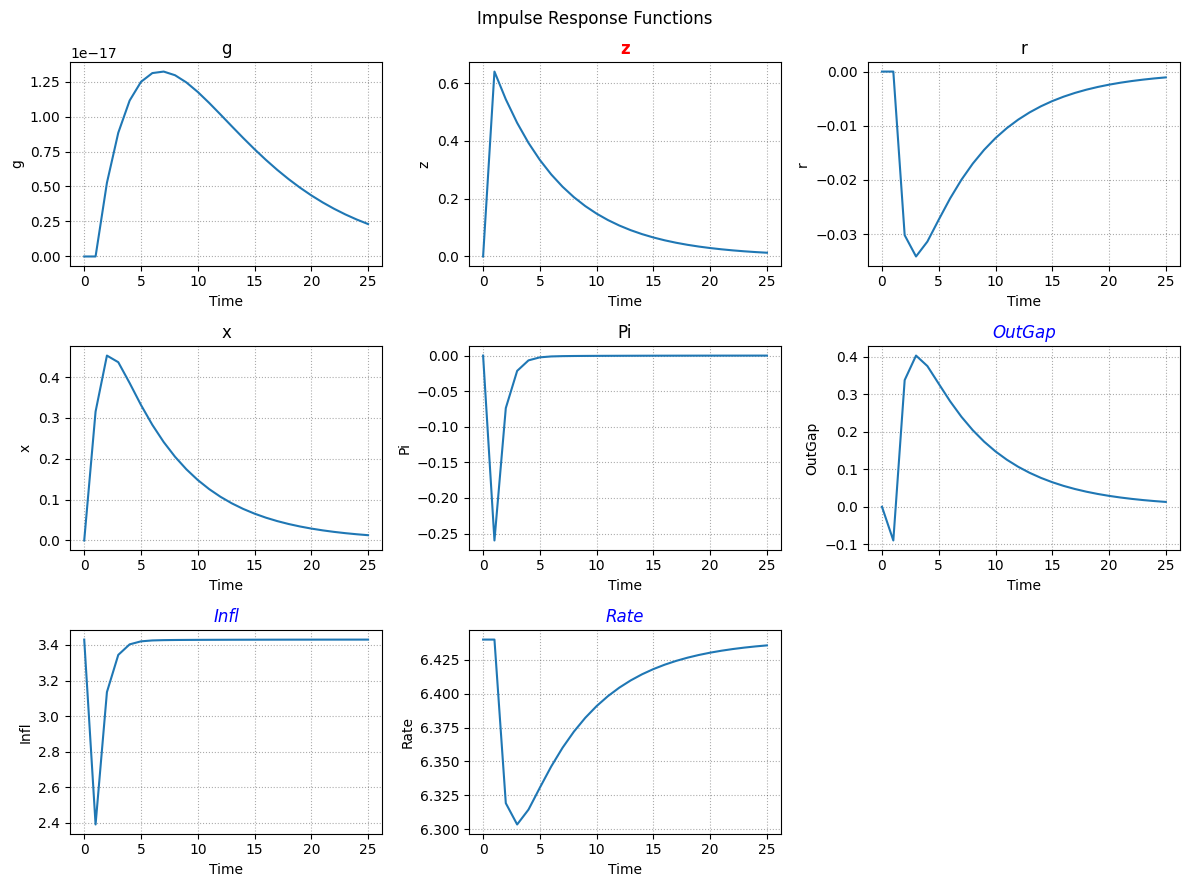

In [38]:
sol_aug.transition_plot(
    T=25,
    observables=True,
    shocks=["z"],
    scale=1.0,
)